# MiloDE on Stat3

# To do:
- filter by CDR (not just minimum expression) <--- most important
- Use embryo as covariate instead of sample <--- 2nd most important
- Optimize Nhoods
- Downstream analysis (GO??)
- Set WGCNA filter for Nhoods genes are differential in to higher number (since more Nhoods present in the data)

In [1]:
suppressPackageStartupMessages({
    library(miloDE)
    library(scuttle)
    suppressMessages(library(miloR))
    suppressMessages(library(uwot))
    library(scran)
    suppressMessages(library(dplyr))
    library(reshape2)
    library(scWGCNA)
    suppressMessages(library(Seurat))
    library(ggplot2)
    library(viridis)
    library(ggpubr)
    library(BiocParallel)
    library(data.table)
})
ncores = 16
mcparam = MulticoreParam(workers = ncores)
register(mcparam)

ERROR: Error in library(miloDE): there is no package called ‘miloDE’


In [95]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/"
source(paste0(main, "code/settings.R"))
source(paste0(main, "code/utils.R"))

args = list() 
args$outdir = file.path(main, 'results/rna/MiloDE/')
args$metadata <- paste0(main,"/results/rna/mapping/sample_metadata_after_mapping.txt.gz")
args$sce <- '/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/processed/SingleCellExperiment.rds'
args$stage = 'E9.5'
args$tdTom_corr = 'False'
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

test = FALSE

In [96]:
sample_metadata <- fread(args$metadata) %>%
   .[pass_rnaQC==TRUE & doublet_call==FALSE & stage %in% args$stage] %>%
    .[,pool:=stringr::str_replace_all(sample,opts$sample2pool)]


if(args$tdTom_corr!='True'){
    sample_metadata = sample_metadata[tdTom==tdTom_corr]
}

if(test){
    sample_metadata = sample_metadata[sample(1:nrow(sample_metadata), nrow(sample_metadata)/10)]
}

###############
## Load data ##
###############

# Load RNA expression data as SingleCellExperiment object
sce <- load_SingleCellExperiment(args$sce, cells=sample_metadata$cell, normalise = TRUE)

# Add sample metadata as colData
colData(sce) <- sample_metadata %>% tibble::column_to_rownames("cell") %>% DataFrame

In [97]:
# Umap -> doesn't currently give option to chose NN & dist of final umap
pca_file = sprintf("%s/results/rna/dimensionality_reduction/sce/pca_features2500_pcs40.txt.gz", main)
pca = fread(pca_file)[match(colnames(sce), cell)] %>% tibble::column_to_rownames("cell") %>% as.matrix
reducedDim(sce,"pca.corrected") = pca

In [98]:
# Umap -> doesn't currently give option to chose NN & dist of final umap
umap_file = sprintf("%s/results/rna/dimensionality_reduction/sce/umap_features2500_pcs40_neigh30_dist0.3.txt.gz", main)
umap = fread(umap_file)[match(colnames(sce), cell)] %>% tibble::column_to_rownames("cell") %>% as.matrix

reducedDim(sce,"UMAP") = umap

In [136]:
# Filter genes
# Get gene metadata
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & ens_id%in%rownames(sce)] %>%
  .[!duplicated(symbol)]

# Imprinted genes
imprint = gene_metadata[c(grep('maternally', gene_metadata$description),
                       grep('paternally', gene_metadata$description)), symbol]

genes_keep = rownames(sce) %>%
    .[grep("^Rik|Rik$|^mt-|^Rps|^Rpl|^Gm",.,invert=T)] %>% # filter out non-informative genes
#    .[grep("^Hbb|^Hba",rn,invert=T)] %>% # Removing Haem genes due to spilling over from erythroids to other cells 
    .[!. %in% c(imprint, 'Grb10', 'Nnat')] %>%  # remove imprinted genes
    .[!. %in% c("Xist", "Tsix")] %>%  # remove Xist & Tsix
    .[!.=="tomato-td"] %>% # remove tomato itself
    .[!.%in%gene_metadata[chr=="chrY",symbol]]

sce = sce[genes_keep,]

In [140]:
args$cdr_threshold = 0.05
CDR = data.table(gene = rownames(sce),
                 cdr_WT = rowMeans(counts(sce[,colData(sce)$tdTom_corr==FALSE])>0),
                 cdr_KO = rowMeans(counts(sce[,colData(sce)$tdTom_corr==TRUE])>0)) %>%
    .[order(-cdr_WT)] %>%
    .[,pass_CDR := ifelse(cdr_WT > args$cdr_threshold | cdr_KO > args$cdr_threshold, TRUE, FALSE)]

sce_filt = sce[CDR[pass_CDR==TRUE, gene], ]

In [141]:
sce_filt

class: SingleCellExperiment 
dim: 11278 21455 
metadata(0):
assays(2): counts logcounts
rownames(11278): Eef1b2 Ptma ... Fam196b Trhde
rowData names(0):
colnames(21455): SLX-21143_SITTA4_HTJH3DSX2#AAACCCAAGAGCAGTC-1
  SLX-21143_SITTA4_HTJH3DSX2#AAACCCAAGCCGATTT-1 ...
  SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGAGGCGCTTC-1
  SLX-21143_SITTH3_HTJH3DSX2#TTTGTTGGTAAGATCA-1
colData names(19): sample barcode ... closest.cell_mnn pool
reducedDimNames(2): pca.corrected UMAP
mainExpName: RNA
altExpNames(0):

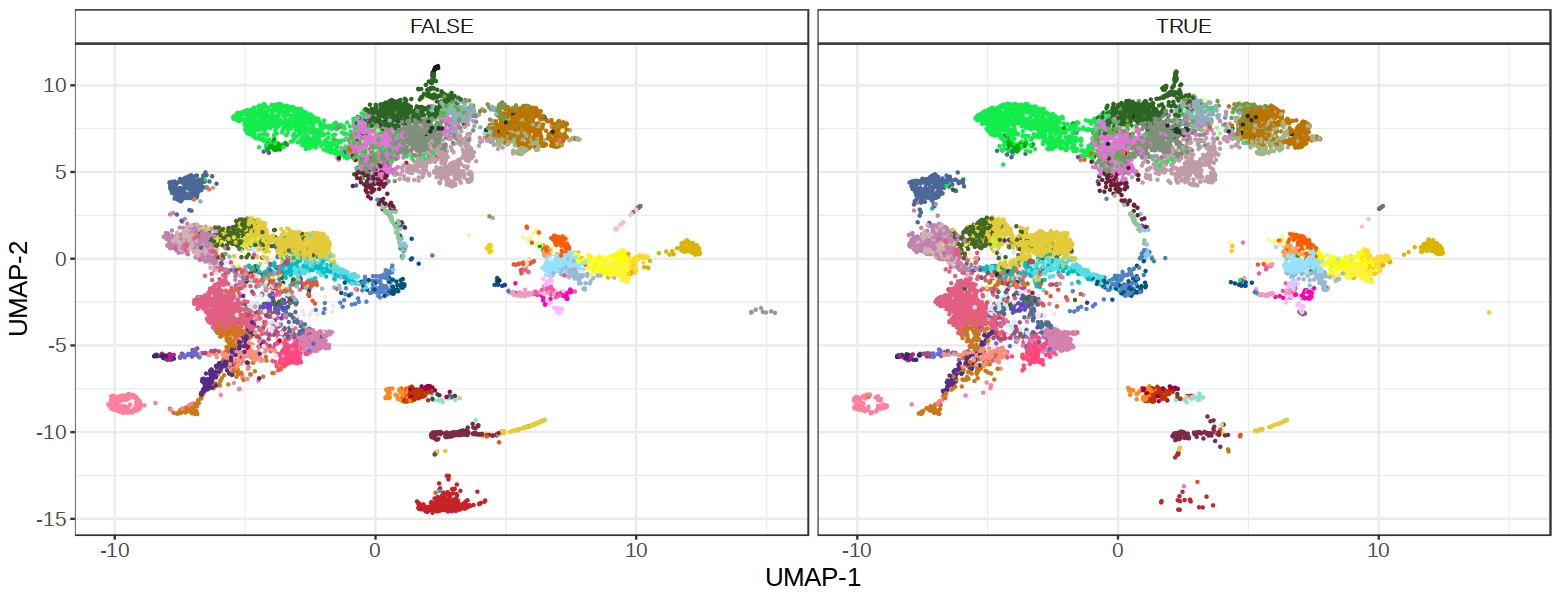

In [142]:
options(repr.plot.height=5, repr.plot.width=13)
# plot UMAPs, colored by cell types
umaps = cbind(as.data.frame(colData(sce)), umap)

p = ggplot(umaps , aes(x = UMAP1, y = UMAP2 , col = celltype.mapped_mnn)) +
  geom_point(size=0.2) + 
  scale_color_manual(values=opts$celltype.colors, name='') +
  facet_wrap(~tdTom) +
  theme_bw() + 
  theme(legend.position='none',
       strip.background=element_rect(fill=NA),
       text=element_text(size=15)) + 
  labs(x = "UMAP-1", y = "UMAP-2")
p

Running for next k values:
10, 15, 20, 25, 30, 35, 40



100% covered by 444 sets.


Finished for k = 10



100% covered by 265 sets.


Finished for k = 15



...

Finished for k = 30



100% covered by 107 sets.


Finished for k = 35



100% covered by 97 sets.


Finished for k = 40

Finished the estimation of neighbourhood sizes ~ k dependancy (order = 2).



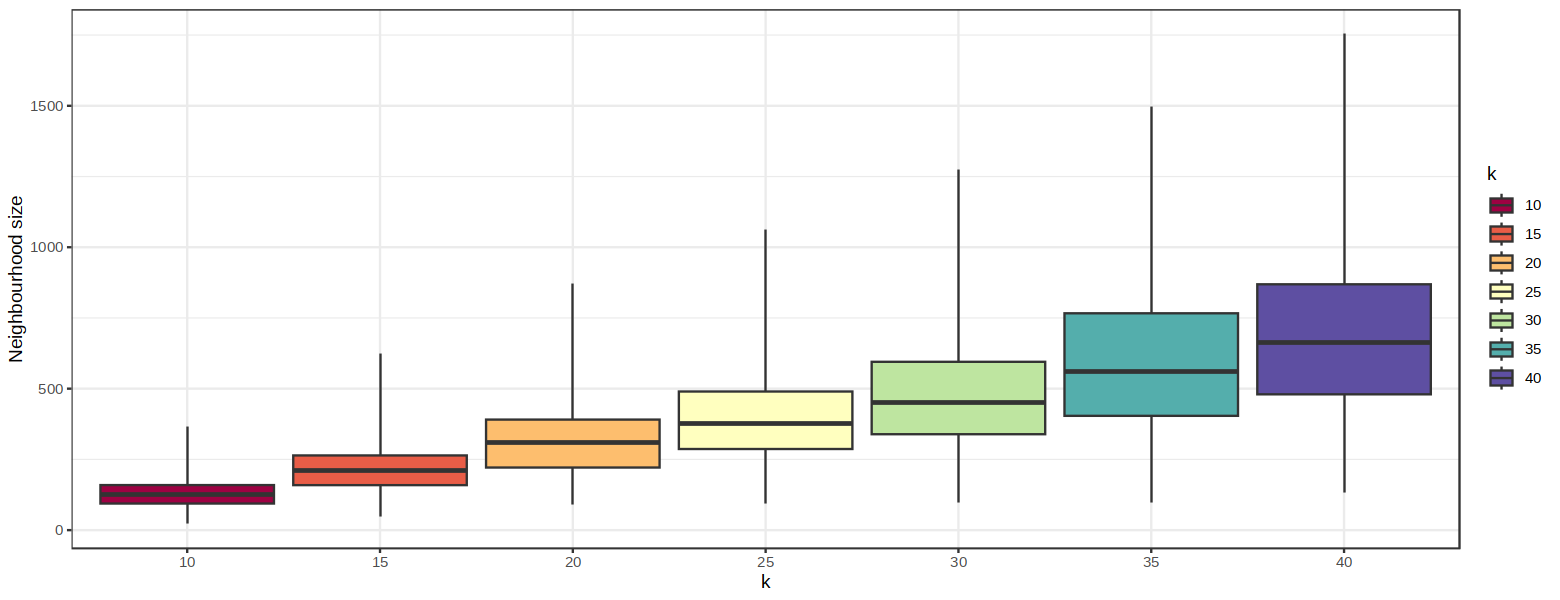

In [143]:
stat_k = estimate_neighbourhood_sizes(sce, k_grid = seq(10,40,5) , 
                                      order = 2, prop = 0.2 , filtering = TRUE,
                                      reducedDim_name = "pca.corrected" , plot_stat = TRUE)

In [144]:
knitr::kable(stat_k , caption = "Neighbourhood size distribution ~ k")



Table: Neighbourhood size distribution ~ k

|k  | min|    q25|   med|    q75|  max|
|:--|---:|------:|-----:|------:|----:|
|10 |  22|  94.00| 125.5| 159.25|  368|
|15 |  48| 159.00| 211.0| 264.00|  625|
|20 |  89| 221.25| 310.0| 390.75|  871|
|25 |  94| 286.75| 377.5| 490.00| 1061|
|30 |  97| 339.00| 451.0| 595.00| 1274|
|35 |  98| 404.00| 561.0| 766.50| 1497|
|40 | 134| 480.00| 663.0| 869.00| 1755|

In [145]:
set.seed(32)
# What does order mean here?
sce_milo = assign_neighbourhoods(sce , k = 25, prop = 0.1, order = 2, 
                                 filtering = TRUE , reducedDim_name = "pca.corrected" , verbose = F)
#> 100% covered by 42 sets.

100% covered by 156 sets.


Converting celltype.mapped_mnn to factor...

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


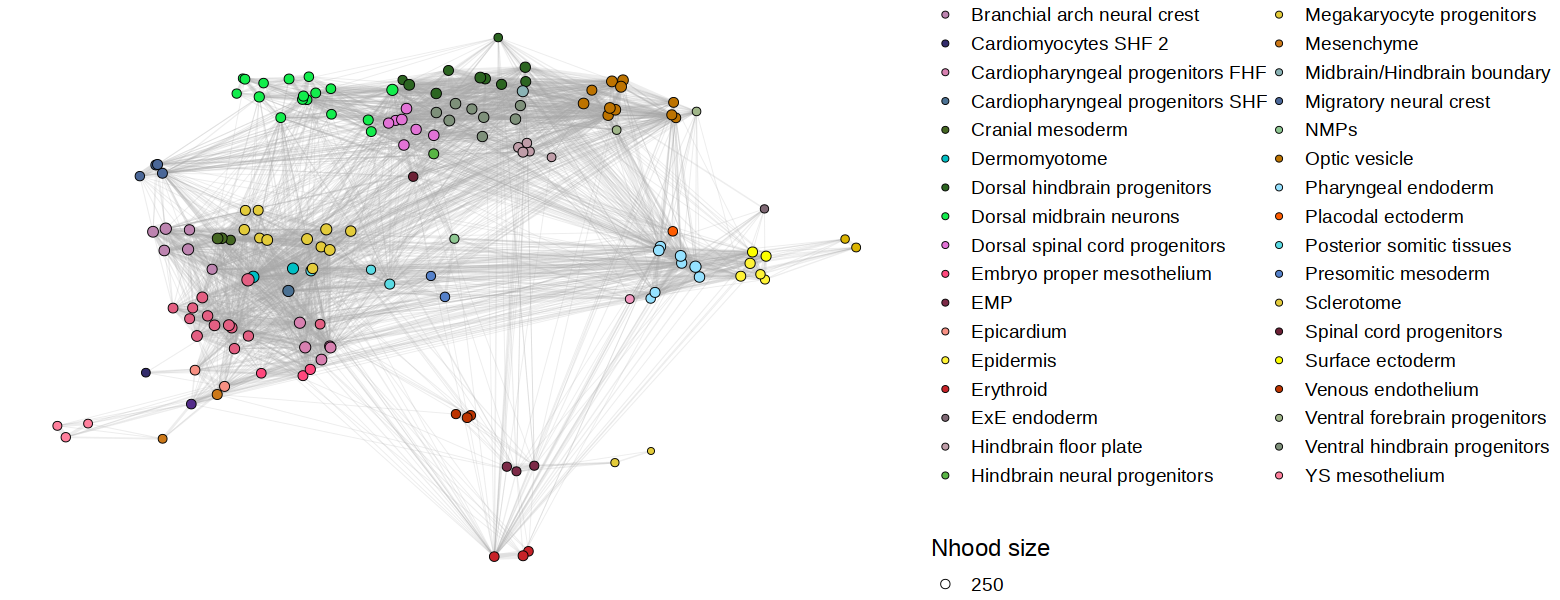

In [146]:
nhoods_sce = nhoods(sce_milo)
# assign cell types for nhoods 
nhood_stat_ct = data.frame(Nhood = 1:ncol(nhoods_sce) , Nhood_center = colnames(nhoods_sce))
nhood_stat_ct = miloR::annotateNhoods(sce_milo , nhood_stat_ct , coldata_col = "celltype.mapped_mnn")
#> Converting seurat_clusters to factor...
p = plot_milo_by_single_metric(sce_milo, nhood_stat_ct, colour_by = "celltype.mapped_mnn" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_manual(values = opts$celltype.colors , name = "celltype.mapped_mnn")
p

In [147]:
# saveRDS(de_stat, sprintf('%s/de_stat.rds', args$outdir))
 saveRDS(sce_milo, sprintf('%s/sce_miloDE_E9.5.rds', args$outdir))

In [3]:
sce_milo = readRDS(sprintf('%s/sce_miloDE_E9.5.rds', args$outdir))

In [148]:
stat_auc = suppressWarnings(calc_AUC_per_neighbourhood(sce_milo , sample_id = "sample" , condition_id = "tdTom", min_n_cells_per_sample = 20, BPPARAM = mcparam))

p = plot_milo_by_single_metric(sce_milo, stat_auc, colour_by = "auc" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "AUC")

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


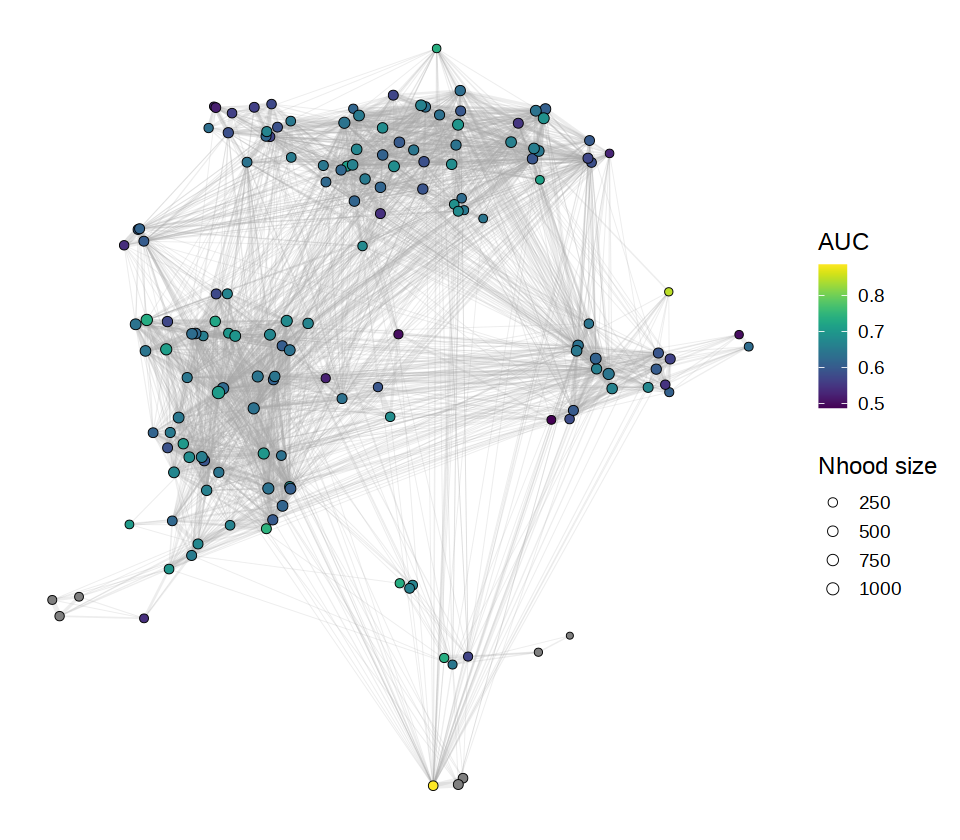

In [149]:
options(repr.plot.height=7, repr.plot.width=8)
p

Starting DE testing within each neighbourhood:

R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send err

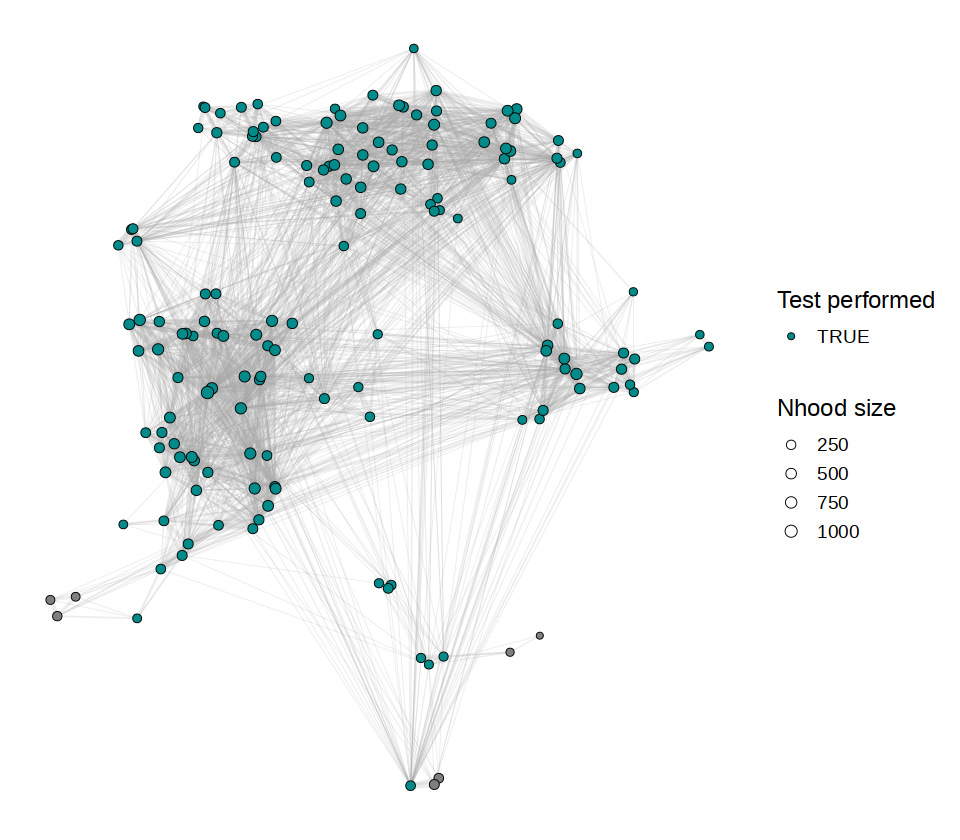

In [150]:
set.seed(7)
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 24

de_stat = de_test_neighbourhoods(sce_milo ,
                             sample_id = "sample",
                             design = ~ pool + tdTom_corr,
                             covariates = c('pool', "tdTom_corr"), # why covariate same as design?
                             min_count = 150,
                             subset_nhoods = stat_auc$Nhood[!is.na(stat_auc$auc)],
                             output_type = "SCE",
                             plot_summary_stat = TRUE,
                             layout = "UMAP", BPPARAM = BPPARAM, 
                             verbose = T)

In [151]:
# de_stat = de_test_neighbourhoods(sce_milo ,
#                              sample_id = "sample",
#                              design = ~pool+tdTom, # -> see if this is the right way to do it
#                              covariates = c("pool", tdTom"), # why covariate same as design?
#                              subset_nhoods = stat_auc$Nhood[!is.na(stat_auc$auc)],
#                              output_type = "SCE",
#                              plot_summary_stat = TRUE,
#                              layout = "umap", BPPARAM = mcparam , 
#                              verbose = F)

In [152]:
head(de_stat)

class: SingleCellExperiment 
dim: 6 149 
metadata(0):
assays(4): logFC pval pval_corrected_across_genes
  pval_corrected_across_nhoods
rownames(6): Mrpl15 Lypla1 ... Rb1cc1 St18
rowData names(0):
colnames(149): 1 2 ... 154 156
colData names(3): Nhood Nhood_center test_performed
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


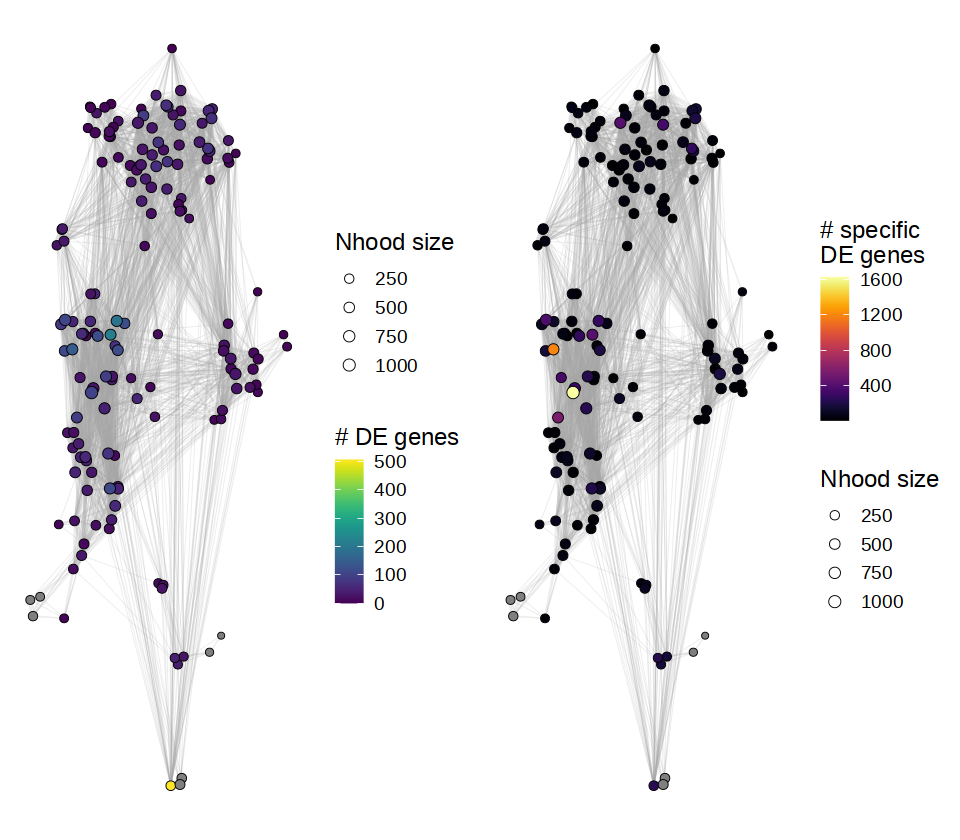

In [153]:
stat_de_magnitude = rank_neighbourhoods_by_DE_magnitude(de_stat)

p1 = plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_DE_genes" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "# DE genes")
#> Warning in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by =
#> "n_DE_genes", : Coercing layout to matrix format
#> Scale for 'fill' is already present. Adding another scale for 'fill', which
#> will replace the existing scale.
p2 = plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_specific_DE_genes" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "# specific\nDE genes" , option = "inferno")
#> Warning in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by =
#> "n_specific_DE_genes", : Coercing layout to matrix format
#> Scale for 'fill' is already present. Adding another scale for 'fill', which
#> will replace the existing scale.
p = ggarrange(p1,p2)
p

Converting de_stat to 'data.frame' format

Converting de_stat to 'data.frame' format

Converting de_stat to 'data.frame' format

Converting de_stat to 'data.frame' format



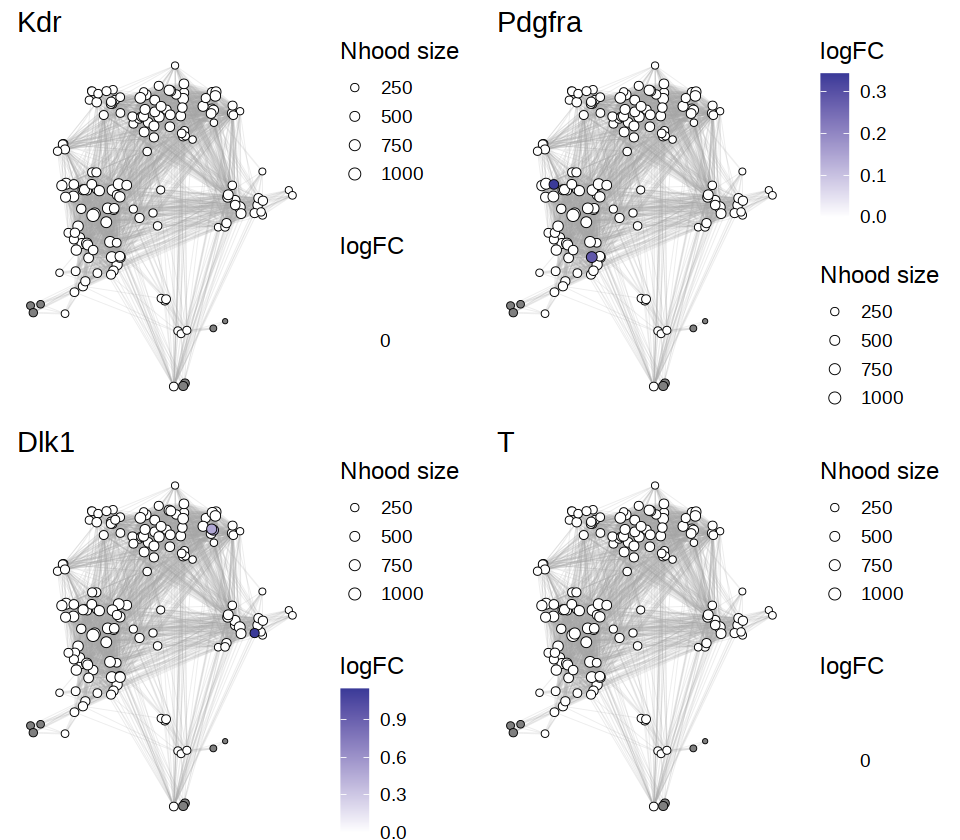

In [154]:
genes = c('Kdr','Pdgfra', 'Dlk1', 'T')
plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "UMAP" , set_na_to_0 = TRUE) + 
    ggtitle(gene)
  return(p)
})

p = ggarrange(plotlist = plots, ncol=2, nrow=2)
p

In [155]:
get_wgcna_modules = function(de_stat , subset_hoods = NULL , 
                             n_hoods_sig.thresh = 2 ,
                             npcs = 5 ,
                             pval.thresh = 0.1 ){
  require(scWGCNA)
  require(Seurat)
  require(dplyr)
  require(reshape2)
  
  set.seed(32)
  # subset hoods
  if (!is.null(subset_hoods)){
    de_stat = de_stat[de_stat$Nhood %in% subset_hoods , ]
  }
  
  # focus on genes that DE in at least 2 nhoods
  de_stat_per_gene = as.data.frame(de_stat %>% group_by(gene) %>% dplyr::summarise(n_hoods_sig = sum(pval_corrected_across_nhoods < pval.thresh , na.rm = TRUE)))
  genes_sig = de_stat_per_gene$gene[de_stat_per_gene$n_hoods_sig >= n_hoods_sig.thresh]
  
  de_stat = de_stat[de_stat$gene %in% genes_sig, ]
  de_stat = de_stat[order(de_stat$Nhood) , ]
  
  # discard neighbourhoods in which testing was not performed
  de_stat = de_stat[de_stat$test_performed , ]
  
  # for this analysis, set logFC to 0 and pvals to 1 if they are NaN
  de_stat$logFC[is.na(de_stat$logFC)] = 0
  de_stat$pval[is.na(de_stat$pval)] = 1
  de_stat$pval_corrected_across_genes[is.na(de_stat$pval_corrected_across_genes)] = 1
  de_stat$pval_corrected_across_nhoods[is.na(de_stat$pval_corrected_across_nhoods)] = 1
  
  # set logFC to 0 if pval_corrected_across_nhoods > pval.thresh
  de_stat$logFC[de_stat$pval_corrected_across_nhoods >= pval.thresh] = 0
  
  # move the object to Seurat
  de_stat = reshape2::dcast(data = de_stat, formula = gene~Nhood, value.var = "logFC")
  rownames(de_stat) = de_stat$gene
  de_stat = de_stat[,2:ncol(de_stat)]
  
  obj.seurat <- CreateSeuratObject(counts = de_stat)
  DefaultAssay(obj.seurat) <- "RNA"
  obj.seurat = FindVariableFeatures(obj.seurat)
  # scale
  obj.seurat[["RNA"]]@scale.data = as.matrix(obj.seurat[["RNA"]]@data)
  obj.seurat = RunPCA(obj.seurat , npcs = npcs)
  
  # run scwgcna
  clusters_scwgcna = run.scWGCNA(p.cells = obj.seurat, 
                                 s.cells = obj.seurat, 
                                 is.pseudocell = F, 
                                 features = rownames(obj.seurat),
                                 less = TRUE , merging = TRUE)
  # compile stat
  clusters = lapply(1:length(clusters_scwgcna$module.genes) , function(i){
    out = data.frame(cluster = i , gene = clusters_scwgcna$module.genes[[i]] , n_genes = length(clusters_scwgcna$module.genes[[i]]))
    return(out)
  })
  clusters = do.call(rbind , clusters)
  # add colors
  genes_w_colors = clusters_scwgcna$dynamicCols
  genes_w_colors = data.frame(gene = names(genes_w_colors) , cluster_color = genes_w_colors)
  clusters = merge(clusters , genes_w_colors)
  
  return(clusters)
}


Warning message in eval(predvars, data, env):
“NaNs produced”
Warning message in hvf.info$variance.expected[not.const] <- 10^fit$fitted:
“number of items to replace is not a multiple of replacement length”


[1] "We have 857 genes in the variable genes object"


Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”
Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'y'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      1    0.132 23.000         0.2130  429.00  4.29e+02  448.0
2      2    0.215 -9.810         0.0913  220.00  2.18e+02  248.0
3      3    0.784 -9.790         0.8070  116.00  1.12e+02  147.0
4      4    0.774 -5.440         0.8370   62.90  5.89e+01   94.6
5      5    0.745 -3.490         0.8270   35.50  3.15e+01   67.0
6      6    0.736 -2.520         0.8140   21.10  1.72e+01   51.9
7      7    0.752 -1.990         0.8090   13.40  9.57e+00   43.2
8      8    0.772 -1.590         0.8150    9.17  5.47e+00   37.9
9      9    0.791 -1.360         0.8340    6.75  3.24e+00   34.4
10    10    0.783 -1.230         0.7880    5.32  2.01e+00   32.0
11    12    0.793 -1.110         0.7510    3.82  8.18e-01   28.5
12    14    0.803 -1.000         0.7590    3.09  3.81e-01   26.2
13    16    0.755 -0.987         0.6850    2.66  1.93e-01   24.4
14    18    0.780 -0.928         0.7180    2.36  1.07e-01   23.0
15    20    0.784 -0.922 

Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


...

Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module detected"
[1] "No module d

Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.


ERROR: Error in seq.default(cutheight - 5e-04, ifelse(cutheight + 5e-04 > 0.9999, : 'from' must be of length 1


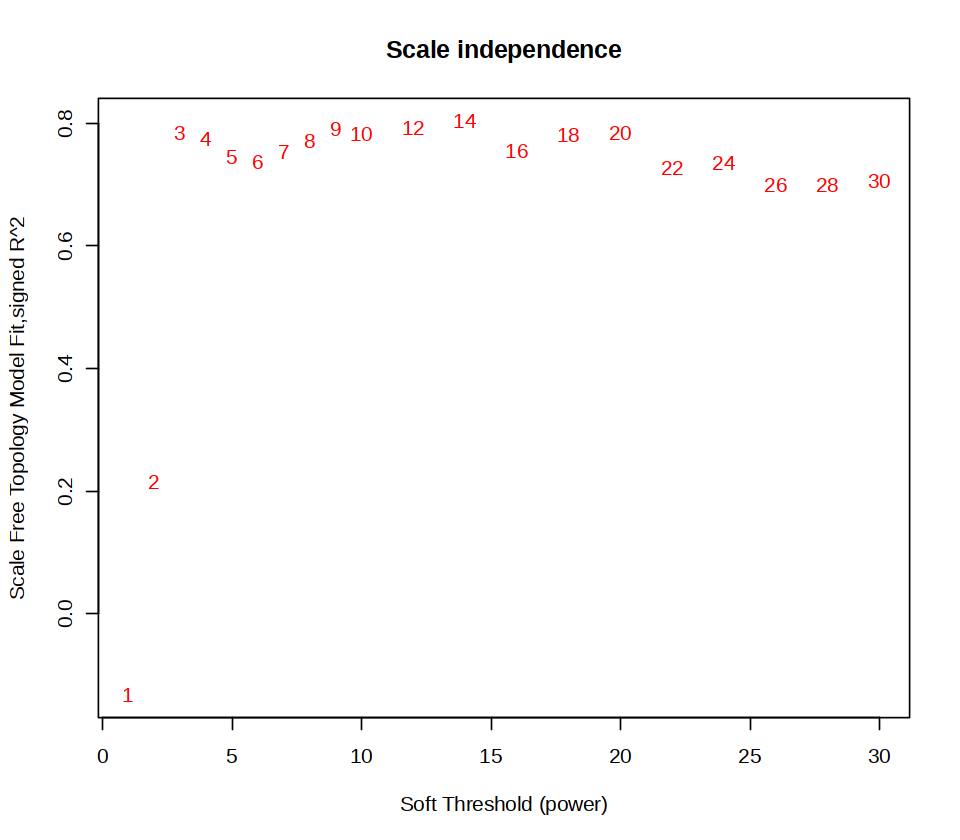

In [156]:
# for this vignette, for simplicity we will focus on genes that are DE in at least 4 neighbourhoods
modules_wgcna = suppressMessages(get_wgcna_modules(convert_de_stat(de_stat) , n_hoods_sig.thresh = 2, pval.thresh = 0.1))

In [ ]:
fwrite(modules_wgcna, sprintf('%s/modules_wgcna.txt.gz', args$outdir))

In [ ]:
plots = mclapply(sort(unique(modules_wgcna$cluster)) , function(cluster){
  p = plot_DE_gene_set(sce_milo, de_stat , genes = modules_wgcna$gene[modules_wgcna$cluster == cluster],
                            layout = "UMAP" , size_range = c(0.5,3) ,
                            node_stroke = 0.3, edge_width = c(0.2,0.5)) +
    ggtitle(paste0("Module ", cluster, ", ", length(modules_wgcna$gene[modules_wgcna$cluster == cluster]) , " genes"))
  return(p)
}, mc.cores=1)

In [ ]:
options(repr.plot.height=5, repr.plot.width=20)
p = ggarrange(plotlist = plots)
p

In [ ]:
# we first need to assign cell type label to each neighbourhood - we have calculated it previously
# we will use data.frame format for de-stat; the conversion between SingleCellExperiment and data.frame formats can be done using `convert_de_stat`
de_stat_df = convert_de_stat(de_stat)
#> Converting de_stat to 'data.frame' format
de_stat_df = merge(de_stat_df , nhood_stat_ct , by = c("Nhood" , "Nhood_center"))


plots = lapply(sort(unique(modules_wgcna$cluster)) , function(cluster){
  p = plot_beeswarm_gene_set(de_stat_df, 
                             genes = modules_wgcna$gene[modules_wgcna$cluster == cluster], 
                             nhoodGroup = "celltype.mapped_mnn") + 
    ggtitle(paste0("Module ", cluster))
  return(p)
})
p = ggarrange(plotlist = plots)
options(repr.plot.height=5, repr.plot.width=30)
p

In [ ]:
genes = head(modules_wgcna[modules_wgcna$cluster == 1,]$gene, 10)

plots = mclapply(genes , function(gene){
  p = suppressWarnings(plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "UMAP" , set_na_to_0 = TRUE)) + 
    ggtitle(gene) + theme(legend.position='none')
  return(p)
}, mc.cores=10)

options(repr.plot.height=5, repr.plot.width=25)
p = ggarrange(plotlist = plots , ncol = 5) 
p

In [ ]:
fwrite(DEGs.dt, sprintf('%s/module_genes.csv', args$outdir))

# Gene Ontology
Filter:
- low P-value
- Number of genes

Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2021... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2021... Done.
Parsing results... Done.


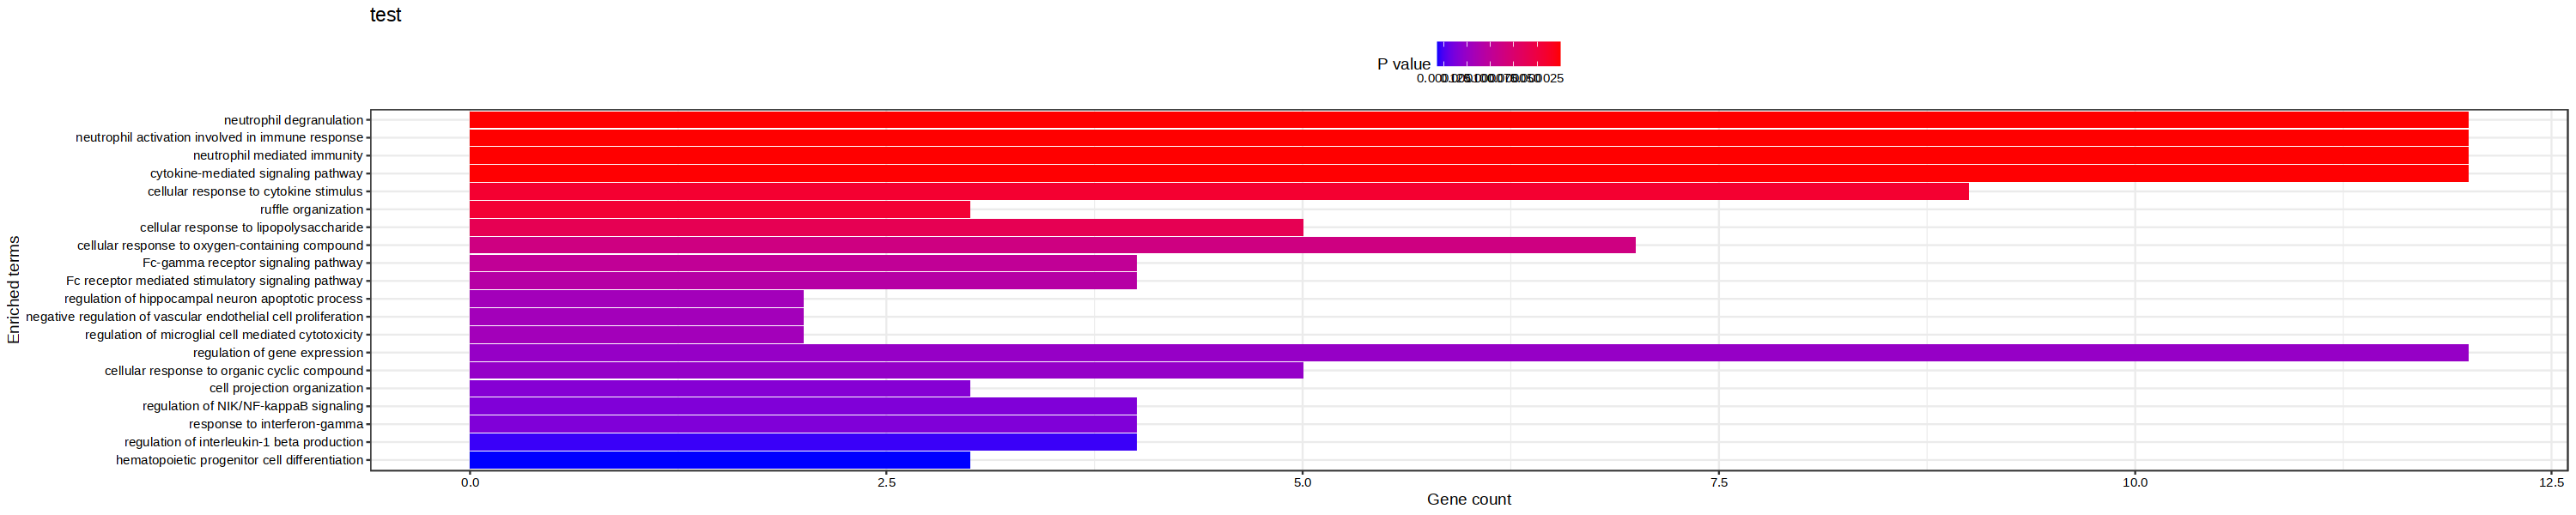

Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2021... Done.
Parsing results... Done.


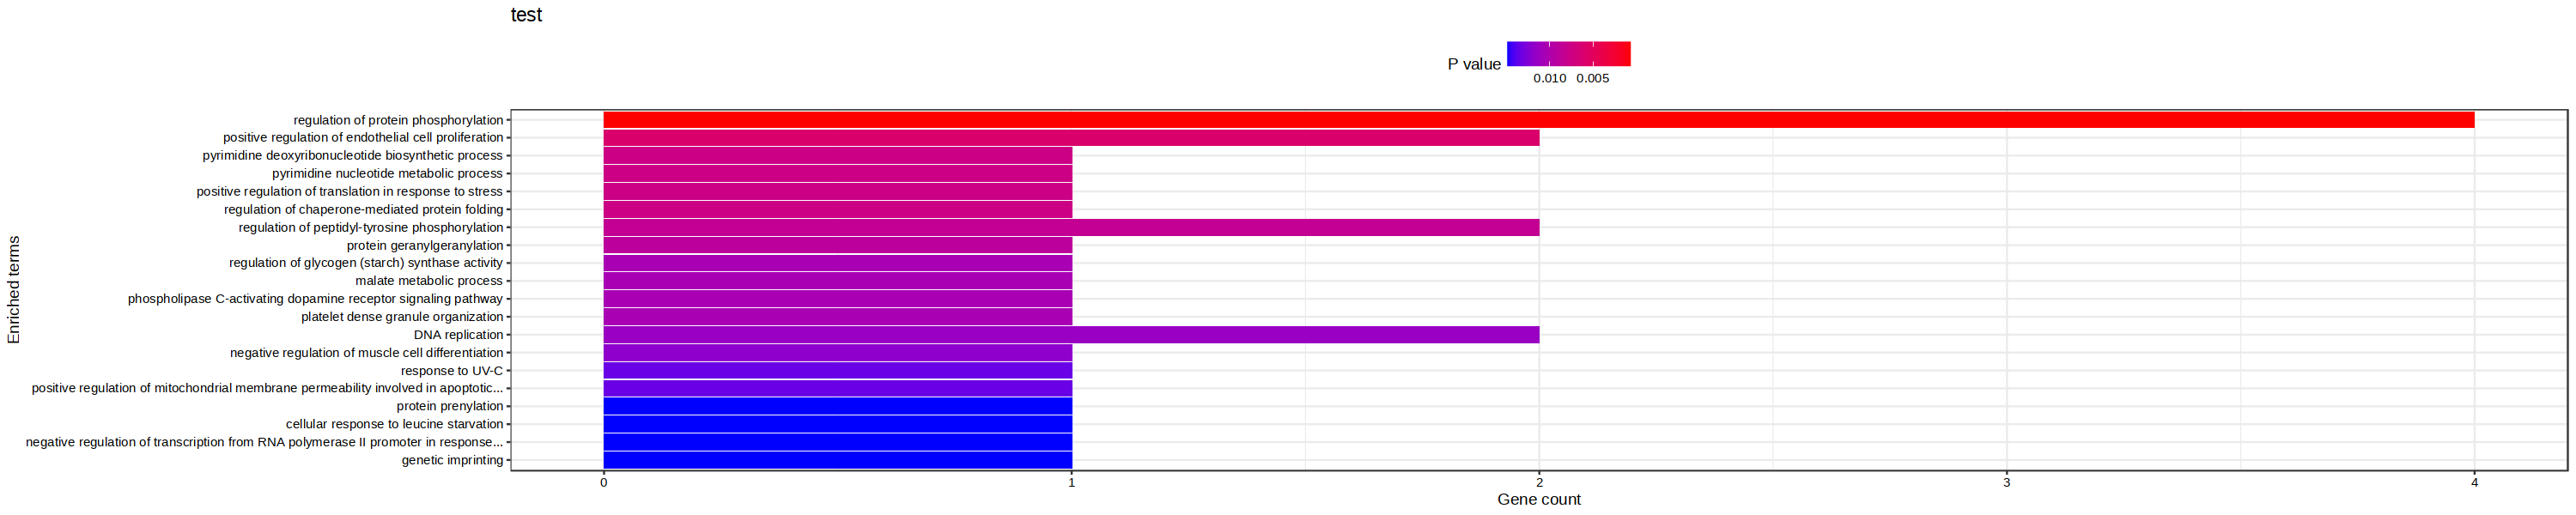

Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2021... Done.
Parsing results... Done.


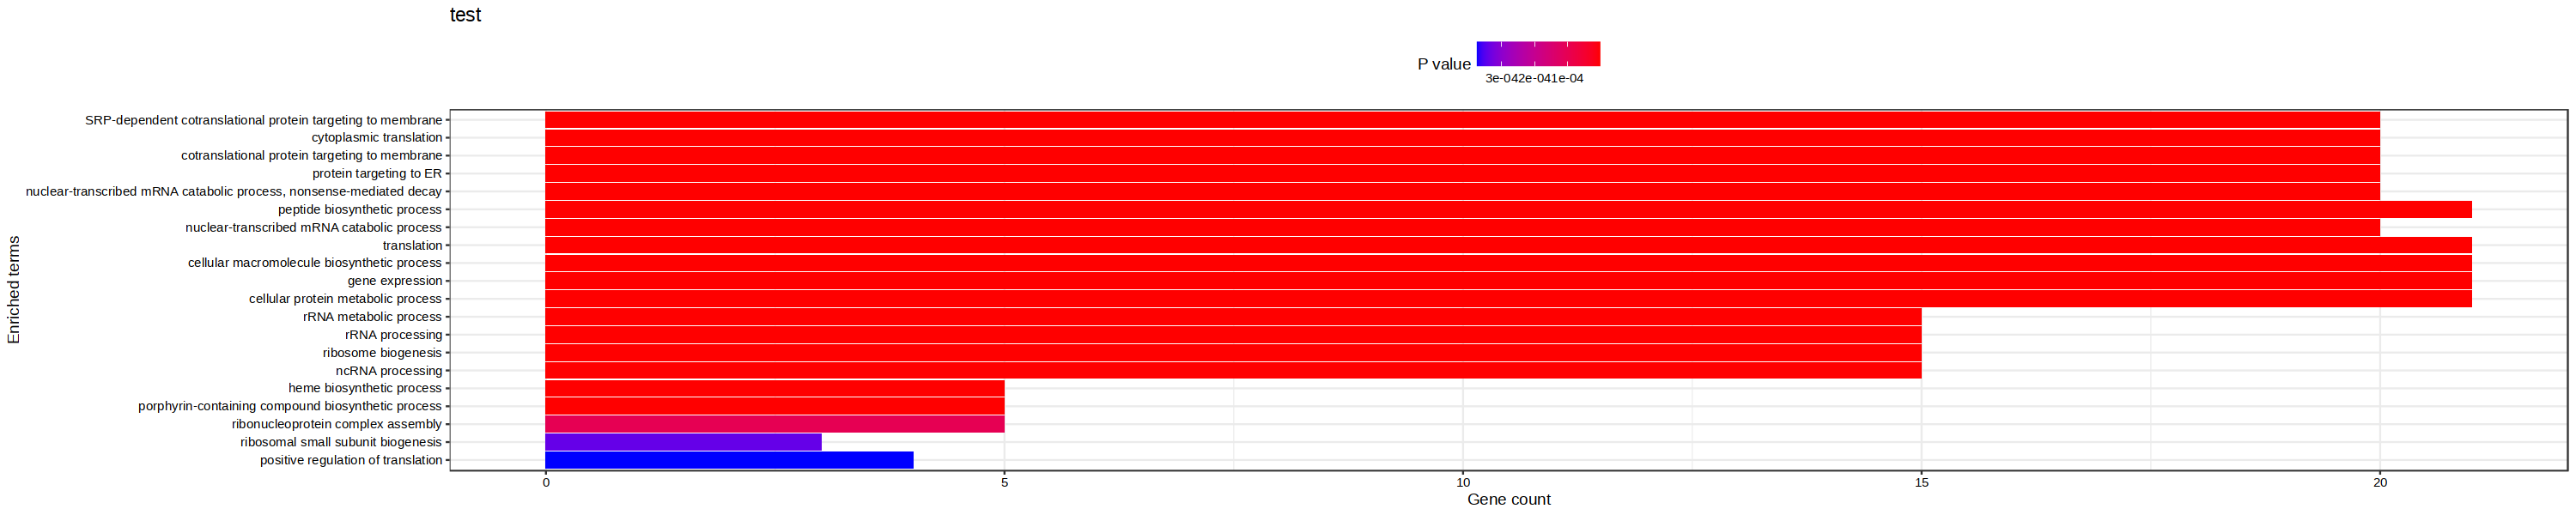

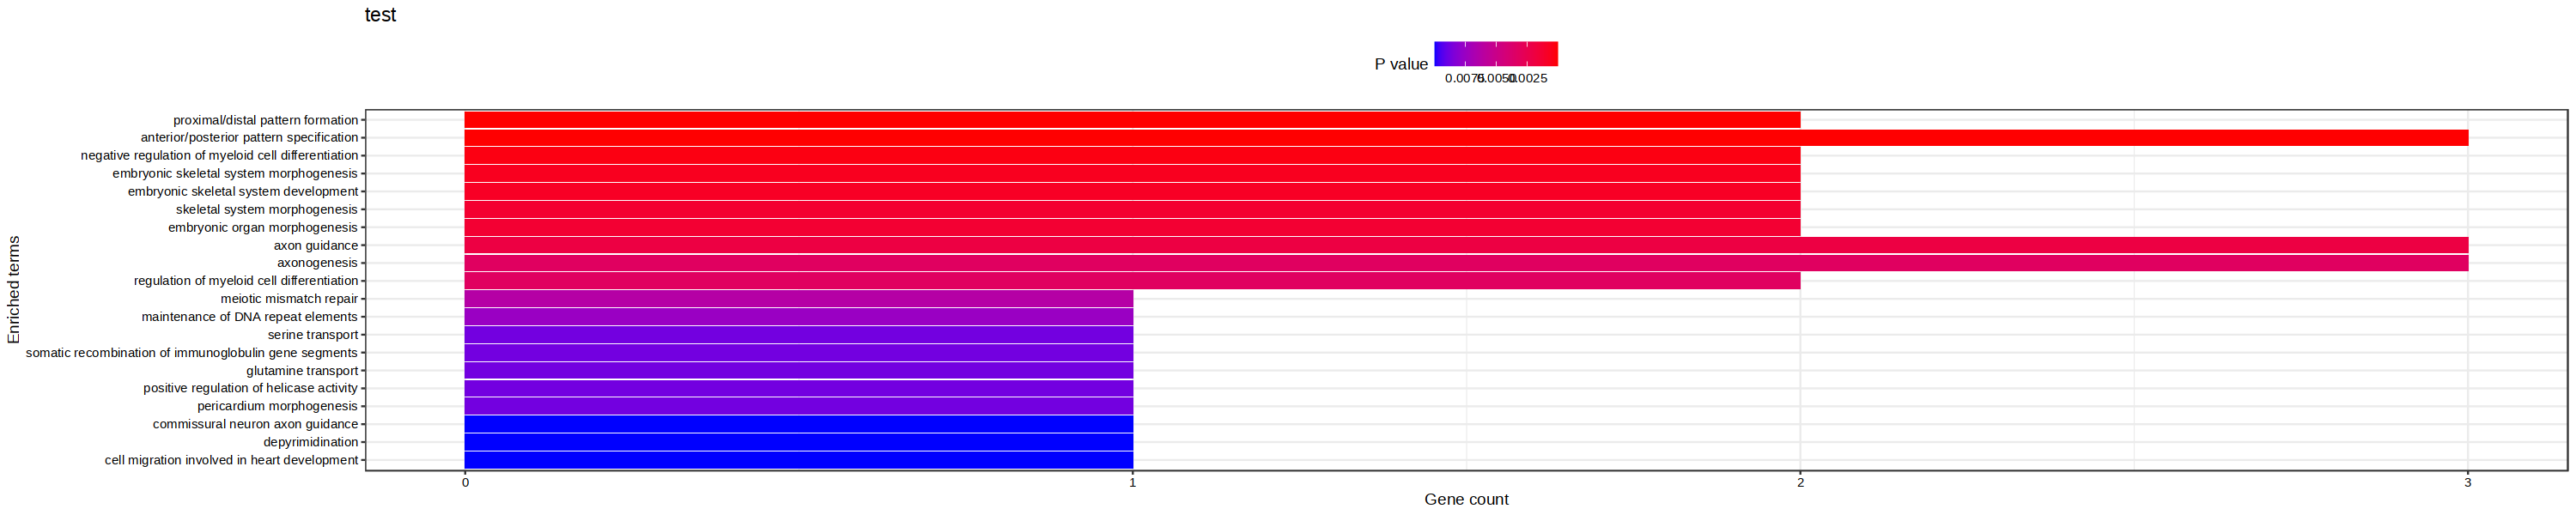

In [134]:
# output also says which genes belong to each ontology


get_go_terms = function(genes){
  library(enrichR)
  library(stringr)
  gos <- as.data.frame( enrichr(genes, 'GO_Biological_Process_2021')[[1]] )
  gos$n_tested_genes = length(genes)
  gos$n_detected_genes_in_go = NaN
  gos$n_total_genes_in_go = NaN
  gos$Term_id = NaN
  for (i in 1:nrow(gos)){
    current.overlap = gos$Overlap[i]
    current.overlap = str_split(current.overlap, '/')
    gos$n_detected_genes_in_go[i] = as.numeric(current.overlap[[1]][1])
    gos$n_total_genes_in_go[i] = as.numeric(current.overlap[[1]][2])
    current.go = gos$Term[i]
    current.go = str_split(current.go, 'GO:')
    gos$Term[i] = substring(current.go[[1]][1], 1, nchar(current.go[[1]][1])-2)
    gos$Term_id[i] = substring(current.go[[1]][2], 1, nchar(current.go[[1]][2])-1)
  }
  return(gos)
}

current.gos = get_go_terms(modules_wgcna[modules_wgcna$cluster == 1,]$gene)

# code to plot 
p = plotEnrich(current.gos , numChar = 80) + ggtitle('test') +
      theme(legend.position = 'top')
p

current.gos = get_go_terms(modules_wgcna[modules_wgcna$cluster == 2,]$gene)

# code to plot 
p = plotEnrich(current.gos , numChar = 80) + ggtitle('test') +
      theme(legend.position = 'top')
p

current.gos = get_go_terms(modules_wgcna[modules_wgcna$cluster == 3,]$gene)

# code to plot 
p = plotEnrich(current.gos , numChar = 80) + ggtitle('test') +
      theme(legend.position = 'top')
p

current.gos = get_go_terms(modules_wgcna[modules_wgcna$cluster == 4,]$gene)

# code to plot 
p = plotEnrich(current.gos , numChar = 80) + ggtitle('test') +
      theme(legend.position = 'top')
p

## Test without pool

Starting DE testing within each neighbourhood:

R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send err

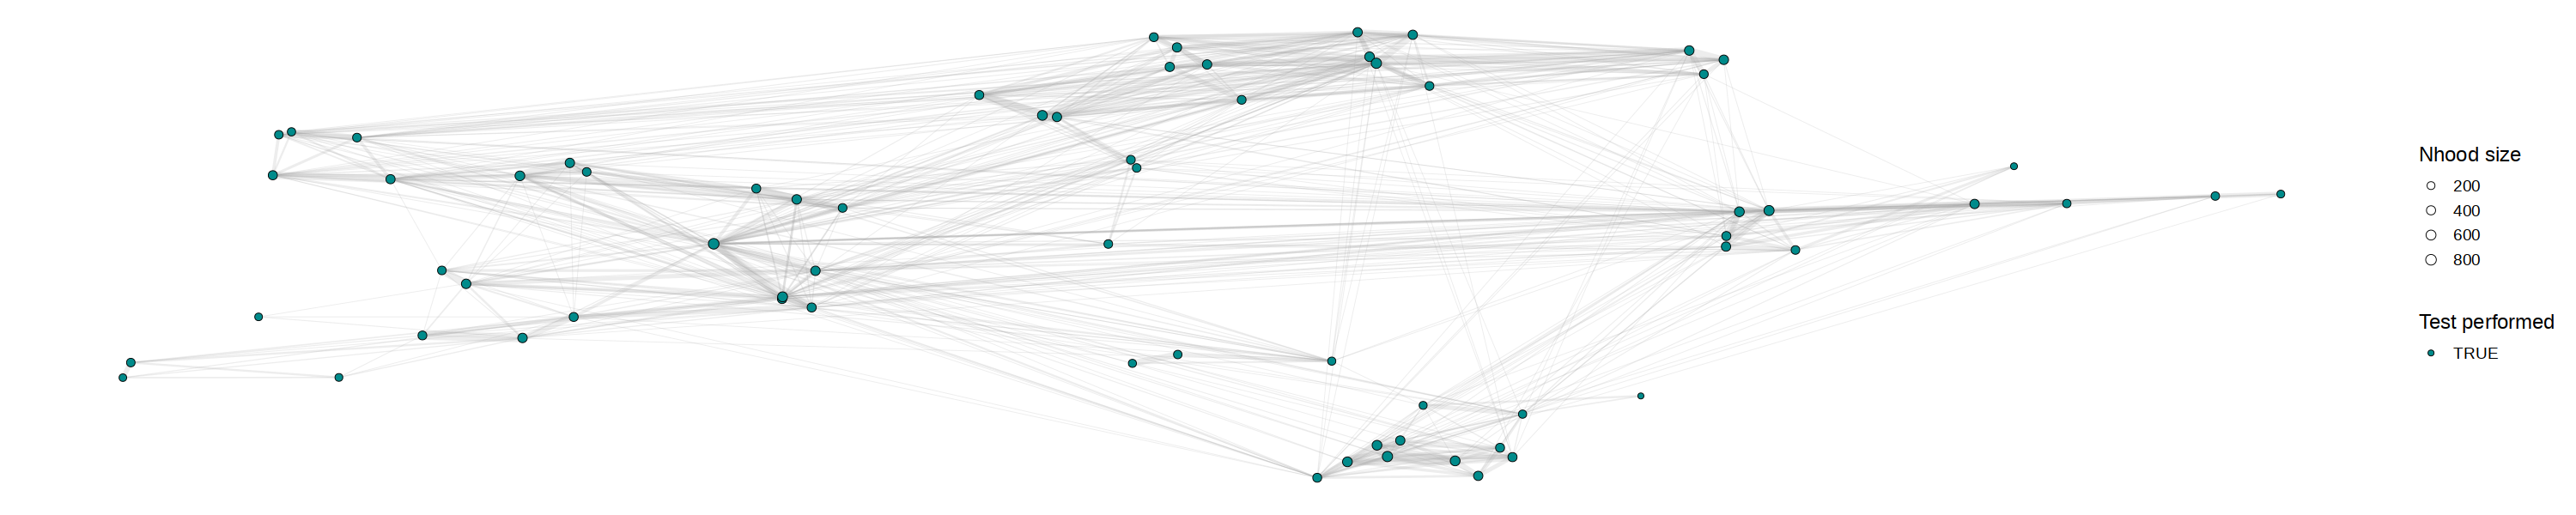

In [86]:
de_stat = de_test_neighbourhoods(sce_milo ,
                             sample_id = "sample",
                             design = ~ tdTom_corr,
                             covariates = c("tdTom_corr"), # why covariate same as design?
                             min_count = 150,
                             subset_nhoods = stat_auc$Nhood[!is.na(stat_auc$auc)],
                             output_type = "SCE",
                             plot_summary_stat = TRUE,
                             layout = "UMAP", BPPARAM = mcparam, 
                             verbose = T)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


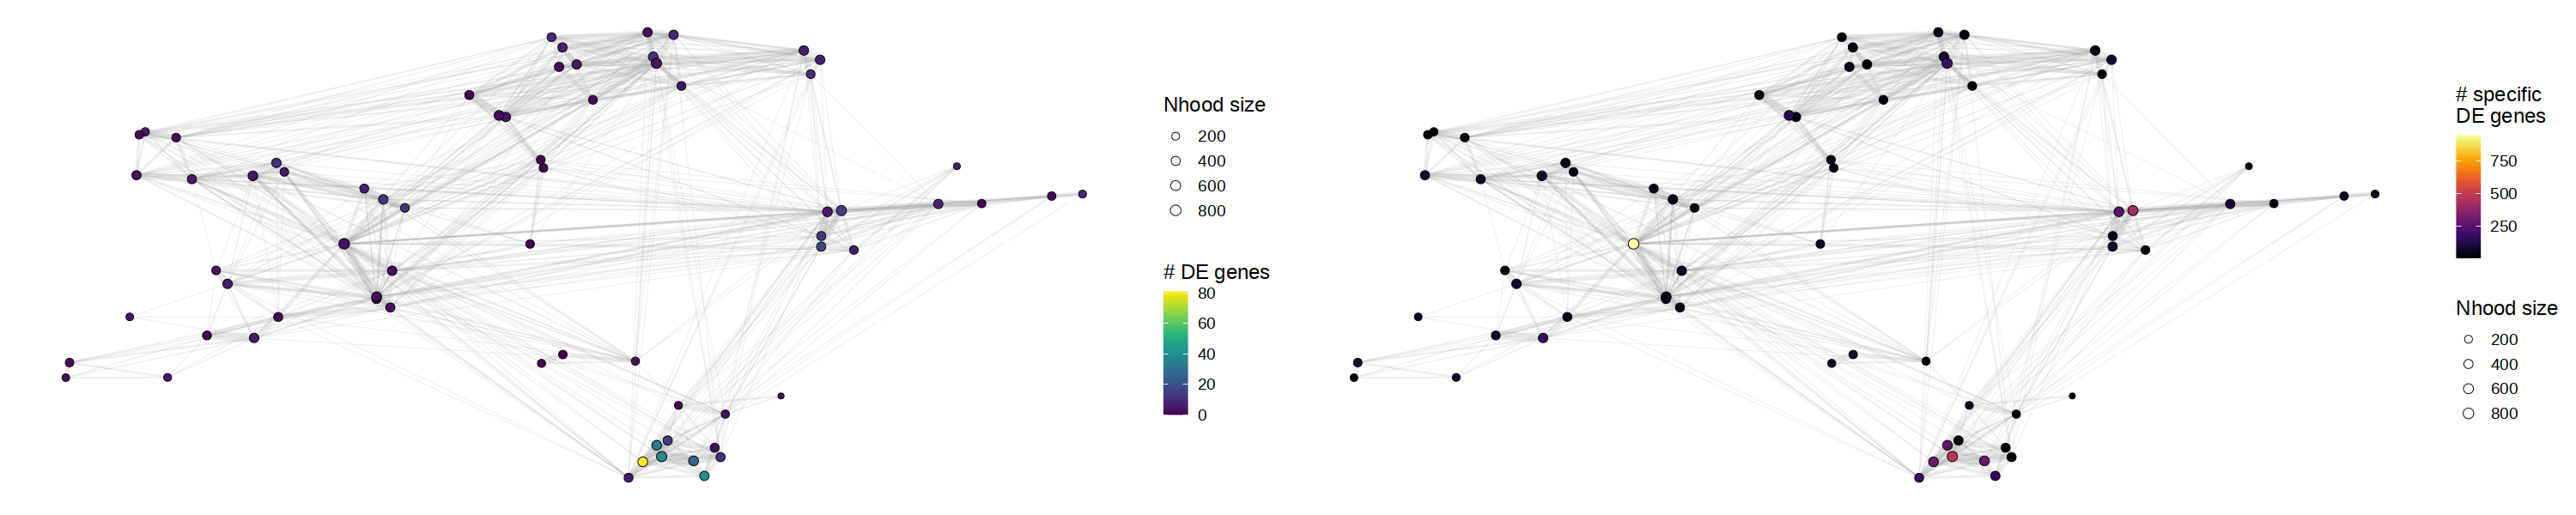

In [88]:
stat_de_magnitude = rank_neighbourhoods_by_DE_magnitude(de_stat)

p1 = plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_DE_genes" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "# DE genes")
#> Warning in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by =
#> "n_DE_genes", : Coercing layout to matrix format
#> Scale for 'fill' is already present. Adding another scale for 'fill', which
#> will replace the existing scale.
p2 = plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_specific_DE_genes" , 
                                      layout = "UMAP" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "# specific\nDE genes" , option = "inferno")
#> Warning in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by =
#> "n_specific_DE_genes", : Coercing layout to matrix format
#> Scale for 'fill' is already present. Adding another scale for 'fill', which
#> will replace the existing scale.
p = ggarrange(p1,p2)
p

Converting de_stat to 'data.frame' format

Converting de_stat to 'data.frame' format

Converting de_stat to 'data.frame' format

Converting de_stat to 'data.frame' format



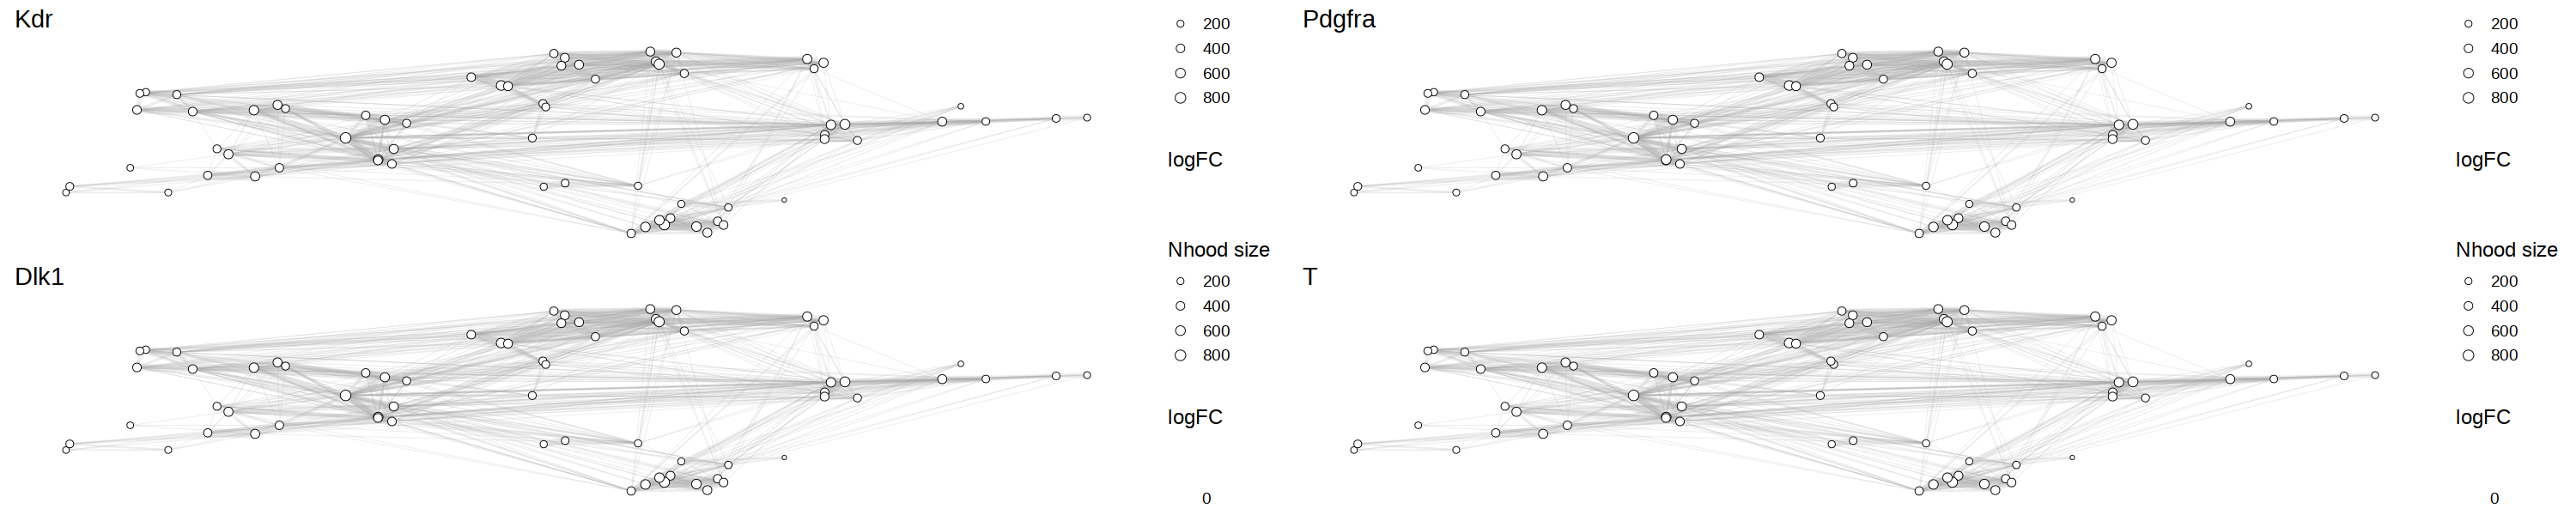

In [92]:
genes = c('Kdr','Pdgfra', 'Dlk1', 'T')
plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "UMAP" , set_na_to_0 = TRUE) + 
    ggtitle(gene)
  return(p)
})

p = ggarrange(plotlist = plots, ncol=2, nrow=2)
p

In [93]:
get_wgcna_modules = function(de_stat , subset_hoods = NULL , 
                             n_hoods_sig.thresh = 2 ,
                             npcs = 5 ,
                             pval.thresh = 0.1 ){
  require(scWGCNA)
  require(Seurat)
  require(dplyr)
  require(reshape2)
  
  set.seed(32)
  # subset hoods
  if (!is.null(subset_hoods)){
    de_stat = de_stat[de_stat$Nhood %in% subset_hoods , ]
  }
  
  # focus on genes that DE in at least 2 nhoods
  de_stat_per_gene = as.data.frame(de_stat %>% group_by(gene) %>% dplyr::summarise(n_hoods_sig = sum(pval_corrected_across_nhoods < pval.thresh , na.rm = TRUE)))
  genes_sig = de_stat_per_gene$gene[de_stat_per_gene$n_hoods_sig >= n_hoods_sig.thresh]
  
  de_stat = de_stat[de_stat$gene %in% genes_sig, ]
  de_stat = de_stat[order(de_stat$Nhood) , ]
  
  # discard neighbourhoods in which testing was not performed
  de_stat = de_stat[de_stat$test_performed , ]
  
  # for this analysis, set logFC to 0 and pvals to 1 if they are NaN
  de_stat$logFC[is.na(de_stat$logFC)] = 0
  de_stat$pval[is.na(de_stat$pval)] = 1
  de_stat$pval_corrected_across_genes[is.na(de_stat$pval_corrected_across_genes)] = 1
  de_stat$pval_corrected_across_nhoods[is.na(de_stat$pval_corrected_across_nhoods)] = 1
  
  # set logFC to 0 if pval_corrected_across_nhoods > pval.thresh
  de_stat$logFC[de_stat$pval_corrected_across_nhoods >= pval.thresh] = 0
  
  # move the object to Seurat
  de_stat = reshape2::dcast(data = de_stat, formula = gene~Nhood, value.var = "logFC")
  rownames(de_stat) = de_stat$gene
  de_stat = de_stat[,2:ncol(de_stat)]
  
  obj.seurat <- CreateSeuratObject(counts = de_stat)
  DefaultAssay(obj.seurat) <- "RNA"
  obj.seurat = FindVariableFeatures(obj.seurat)
  # scale
  obj.seurat[["RNA"]]@scale.data = as.matrix(obj.seurat[["RNA"]]@data)
  obj.seurat = RunPCA(obj.seurat , npcs = npcs)
  
  # run scwgcna
  clusters_scwgcna = run.scWGCNA(p.cells = obj.seurat, 
                                 s.cells = obj.seurat, 
                                 is.pseudocell = F, 
                                 features = rownames(obj.seurat),
                                 less = TRUE , merging = TRUE)
  # compile stat
  clusters = lapply(1:length(clusters_scwgcna$module.genes) , function(i){
    out = data.frame(cluster = i , gene = clusters_scwgcna$module.genes[[i]] , n_genes = length(clusters_scwgcna$module.genes[[i]]))
    return(out)
  })
  clusters = do.call(rbind , clusters)
  # add colors
  genes_w_colors = clusters_scwgcna$dynamicCols
  genes_w_colors = data.frame(gene = names(genes_w_colors) , cluster_color = genes_w_colors)
  clusters = merge(clusters , genes_w_colors)
  
  return(clusters)
}


Warning message in eval(predvars, data, env):
“NaNs produced”
Warning message in hvf.info$variance.expected[not.const] <- 10^fit$fitted:
“number of items to replace is not a multiple of replacement length”


[1] "We have 221 genes in the variable genes object"


Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”
Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'y'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      1    0.242  4.090         0.0977  111.00  111.0000 121.00
2      2    0.217 -3.670         0.6970   61.90   57.8000  81.20
3      3    0.301 -2.190         0.7110   37.10   32.4000  60.30
4      4    0.347 -1.640         0.5910   23.90   18.5000  48.10
5      5    0.483 -1.150         0.7230   16.50   11.0000  40.30
6      6    0.508 -0.957         0.7680   12.10    6.7000  34.80
7      7    0.386 -0.970         0.4310    9.37    4.2400  30.90
8      8    0.586 -0.810         0.7520    7.58    2.7900  27.80
9      9    0.612 -0.784         0.7090    6.33    1.8500  25.30
10    10    0.664 -0.754         0.7090    5.42    1.2000  23.30
11    12    0.767 -0.705         0.8000    4.19    0.6600  20.00
12    14    0.833 -0.706         0.8560    3.38    0.4260  17.60
13    16    0.884 -0.712         0.8870    2.81    0.2530  15.60
14    18    0.883 -0.709         0.8660    2.39    0.1830  14.00
15    20    0.901 -0.719 

Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


...

TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.
[1] "my.height:  0.9941  .... my.Clsize:  15"
5 genes not assigned to any module.
0 genes excluded due to significance.

IMPORTANT NOTE!!!
You have run this analysis witht the option less=TRUE. If a module seems to be highly expressed in only 1-3 cells ( cells expressing >2*(max(expression)/3) ), it will be removed.


Warning message in min(x, na.rm = T):
“no non-missing arguments to min; returning Inf”



Info: Some clusters will be merged
 mergeCloseModules: Merging modules whose distance is less than 0.25
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 4 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 2 module eigengenes in given set.
   Calculating new MEs...
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 2 module eigengenes in given set.

This is the result of the filtering.
The color of the modules does not correspond between original and filtered
TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.


Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.
[1] "my.height:  0.9941  .... my.Clsize:  17"


IMPORTANT NOTE!!!
You have run this analysis witht the option merging=TRUE. This means that based on their expression pattern, modules with similar expression profile (distance < 0.25) be merged during the iterations.
 mergeCloseModules: Merging modules whose distance is less than 0.25
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 4 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 2 module eigengenes in given set.
   Calculating new MEs...
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 2 module eigengenes in given set.
0 genes not assigned to any module.
0 genes exclud

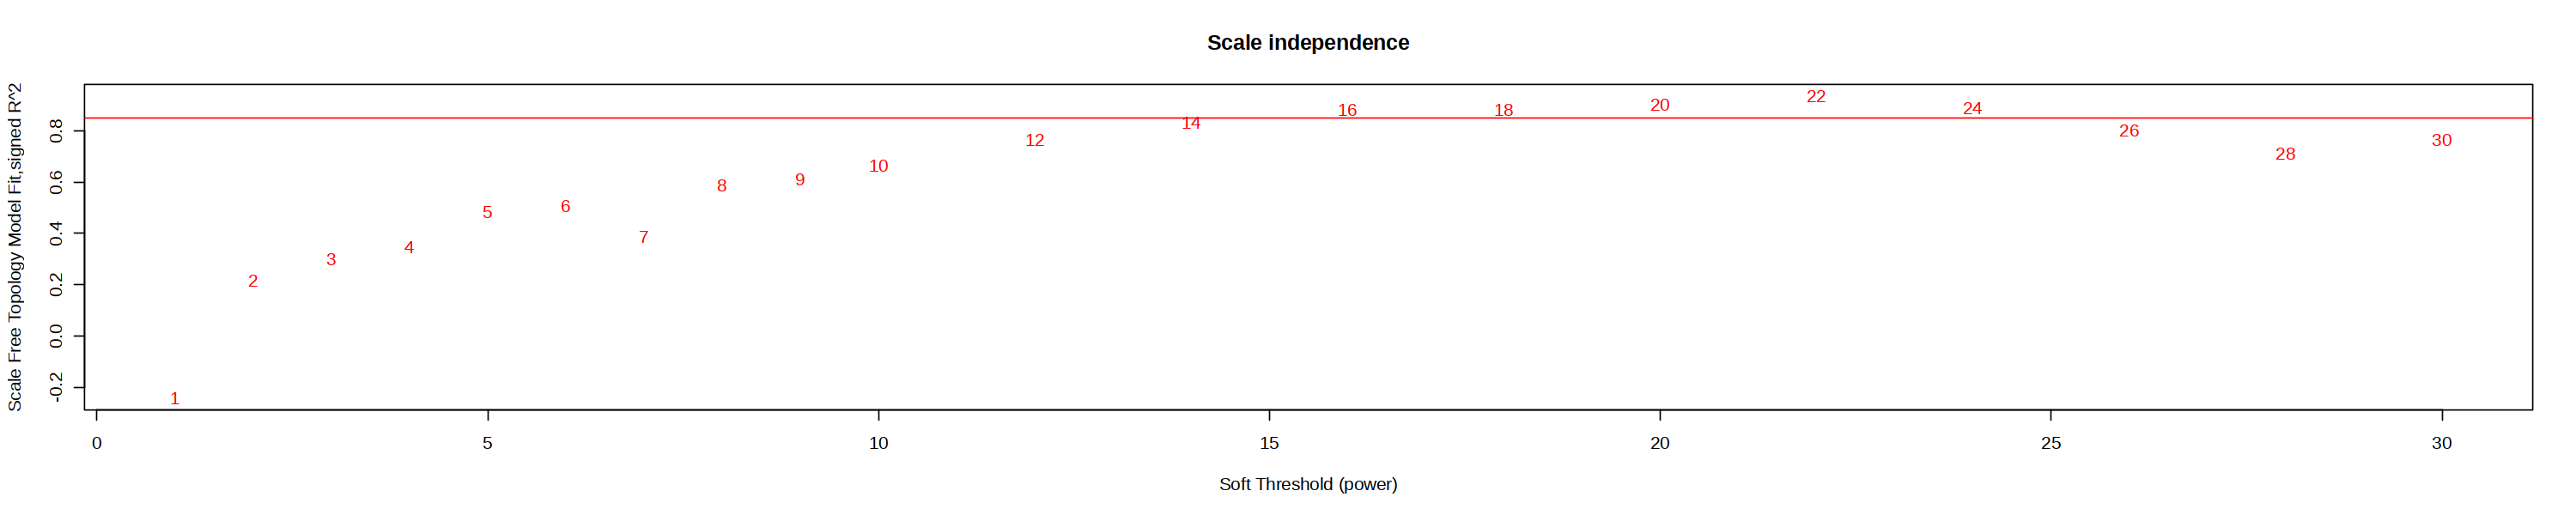

In [94]:
# for this vignette, for simplicity we will focus on genes that are DE in at least 4 neighbourhoods
modules_wgcna = suppressMessages(get_wgcna_modules(convert_de_stat(de_stat) , n_hoods_sig.thresh = 3, pval.thresh = 0.1))

In [19]:
fwrite(modules_wgcna, sprintf('%s/modules_wgcna.txt.gz', args$outdir))

In [81]:
plots = mclapply(sort(unique(modules_wgcna$cluster)) , function(cluster){
  p = plot_DE_gene_set(sce_milo, de_stat , genes = modules_wgcna$gene[modules_wgcna$cluster == cluster],
                            layout = "UMAP" , size_range = c(0.5,3) ,
                            node_stroke = 0.3, edge_width = c(0.2,0.5)) +
    ggtitle(paste0("Module ", cluster, ", ", length(modules_wgcna$gene[modules_wgcna$cluster == cluster]) , " genes"))
  return(p)
}, mc.cores=1)

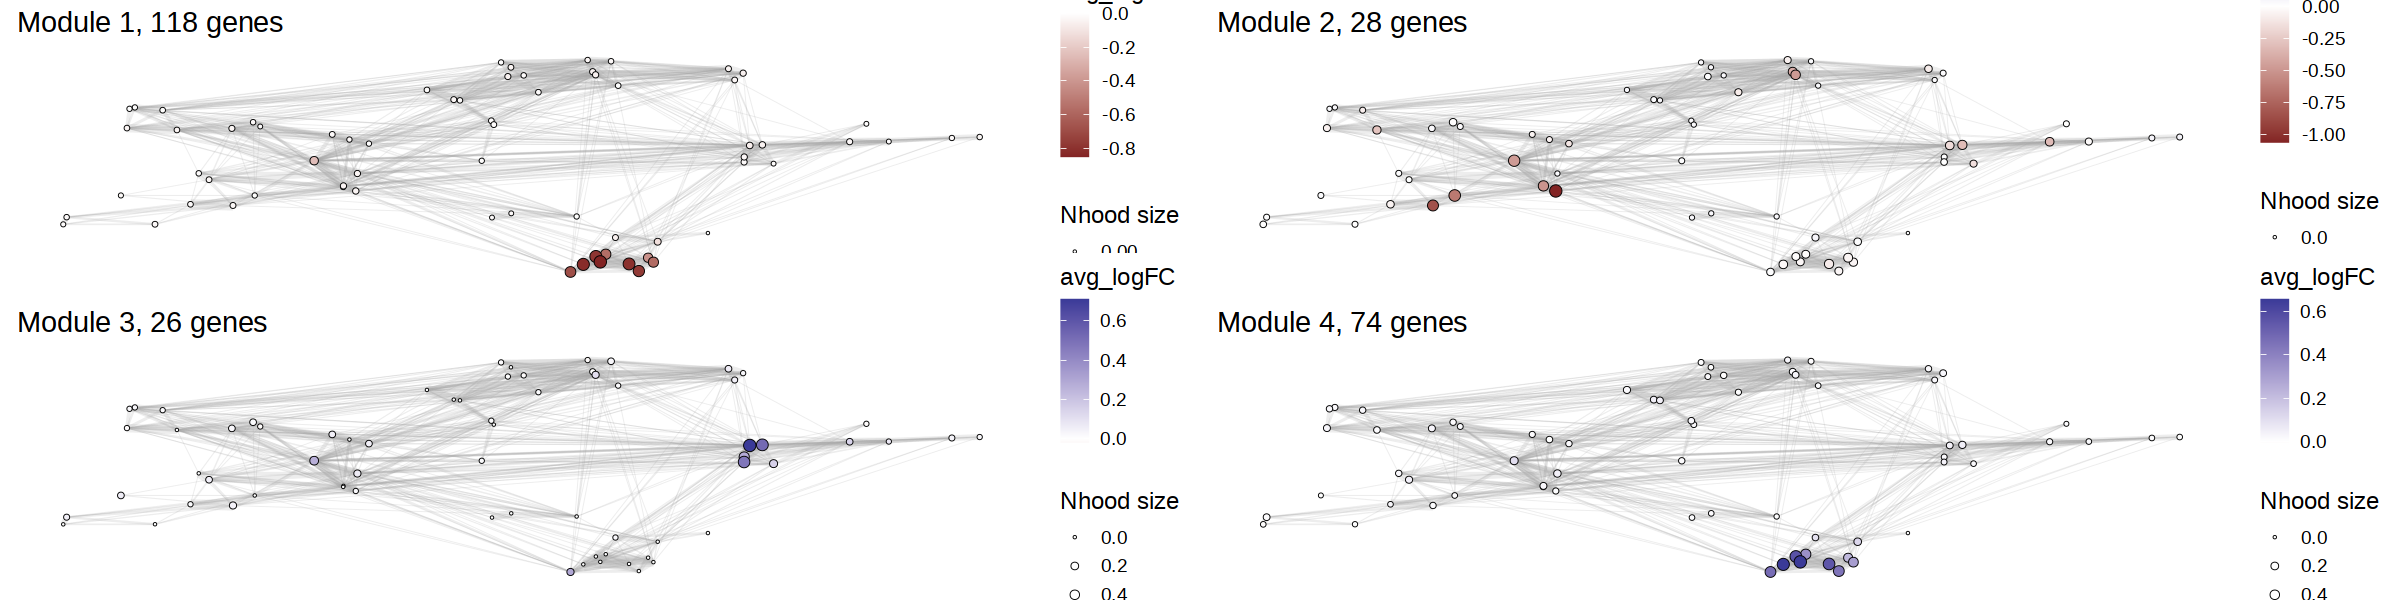

In [82]:
options(repr.plot.height=5, repr.plot.width=20)
p = ggarrange(plotlist = plots)
p

Converting de_stat to 'data.frame' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format



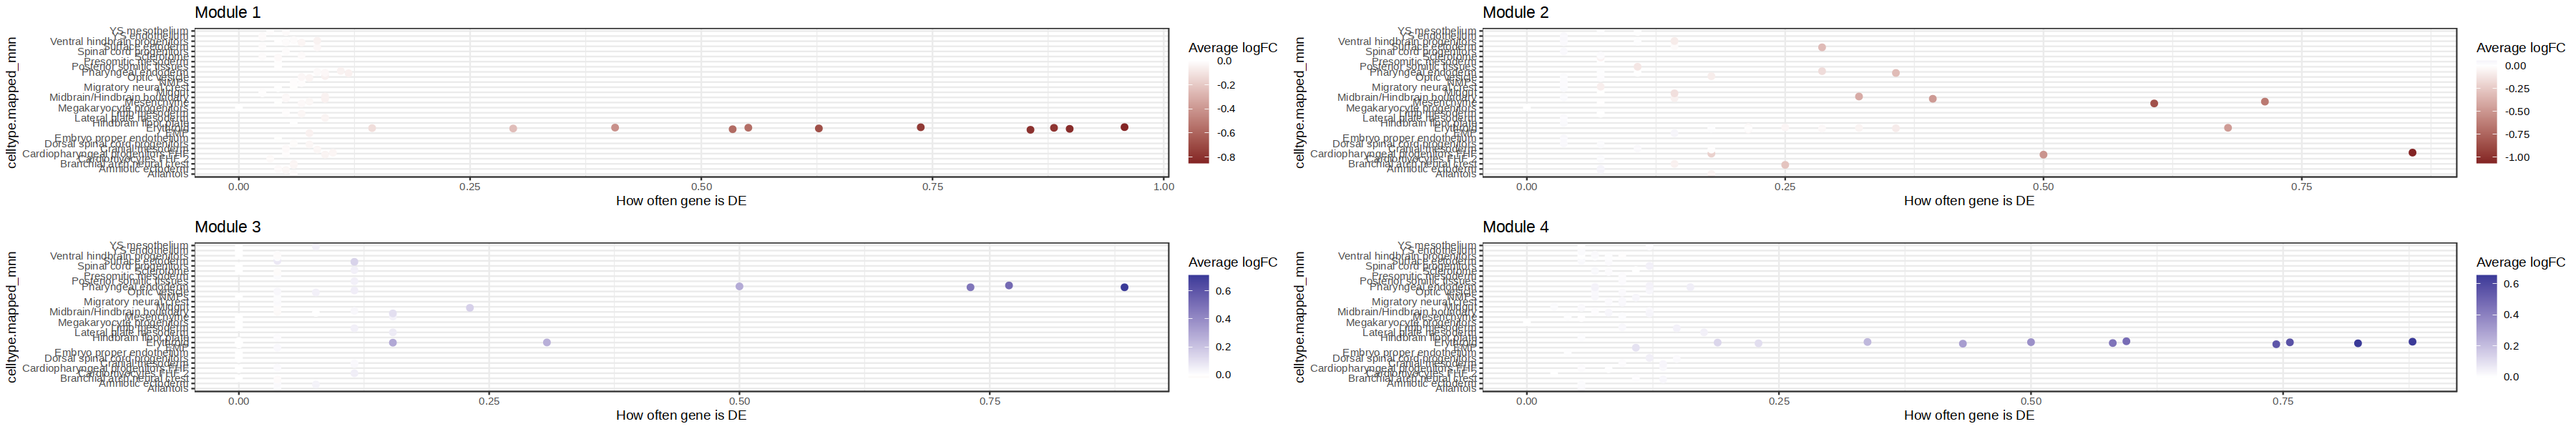

In [83]:
# we first need to assign cell type label to each neighbourhood - we have calculated it previously
# we will use data.frame format for de-stat; the conversion between SingleCellExperiment and data.frame formats can be done using `convert_de_stat`
de_stat_df = convert_de_stat(de_stat)
#> Converting de_stat to 'data.frame' format
de_stat_df = merge(de_stat_df , nhood_stat_ct , by = c("Nhood" , "Nhood_center"))


plots = lapply(sort(unique(modules_wgcna$cluster)) , function(cluster){
  p = plot_beeswarm_gene_set(de_stat_df, 
                             genes = modules_wgcna$gene[modules_wgcna$cluster == cluster], 
                             nhoodGroup = "celltype.mapped_mnn") + 
    ggtitle(paste0("Module ", cluster))
  return(p)
})
p = ggarrange(plotlist = plots)
options(repr.plot.height=5, repr.plot.width=30)
p

$`1`

$`2`

attr(,"class")
[1] "list"      "ggarrange"

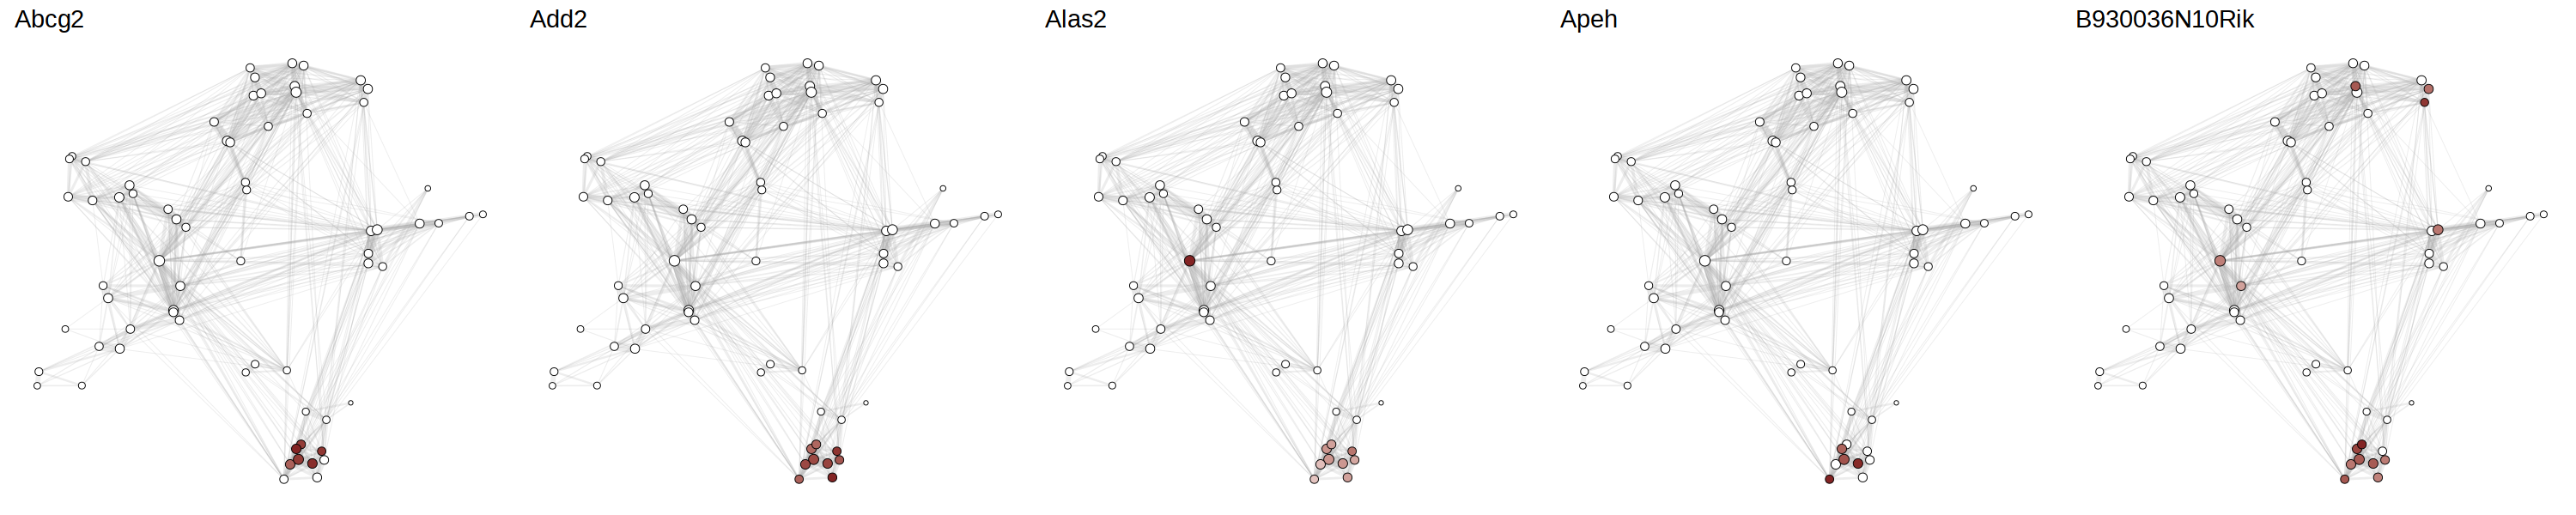

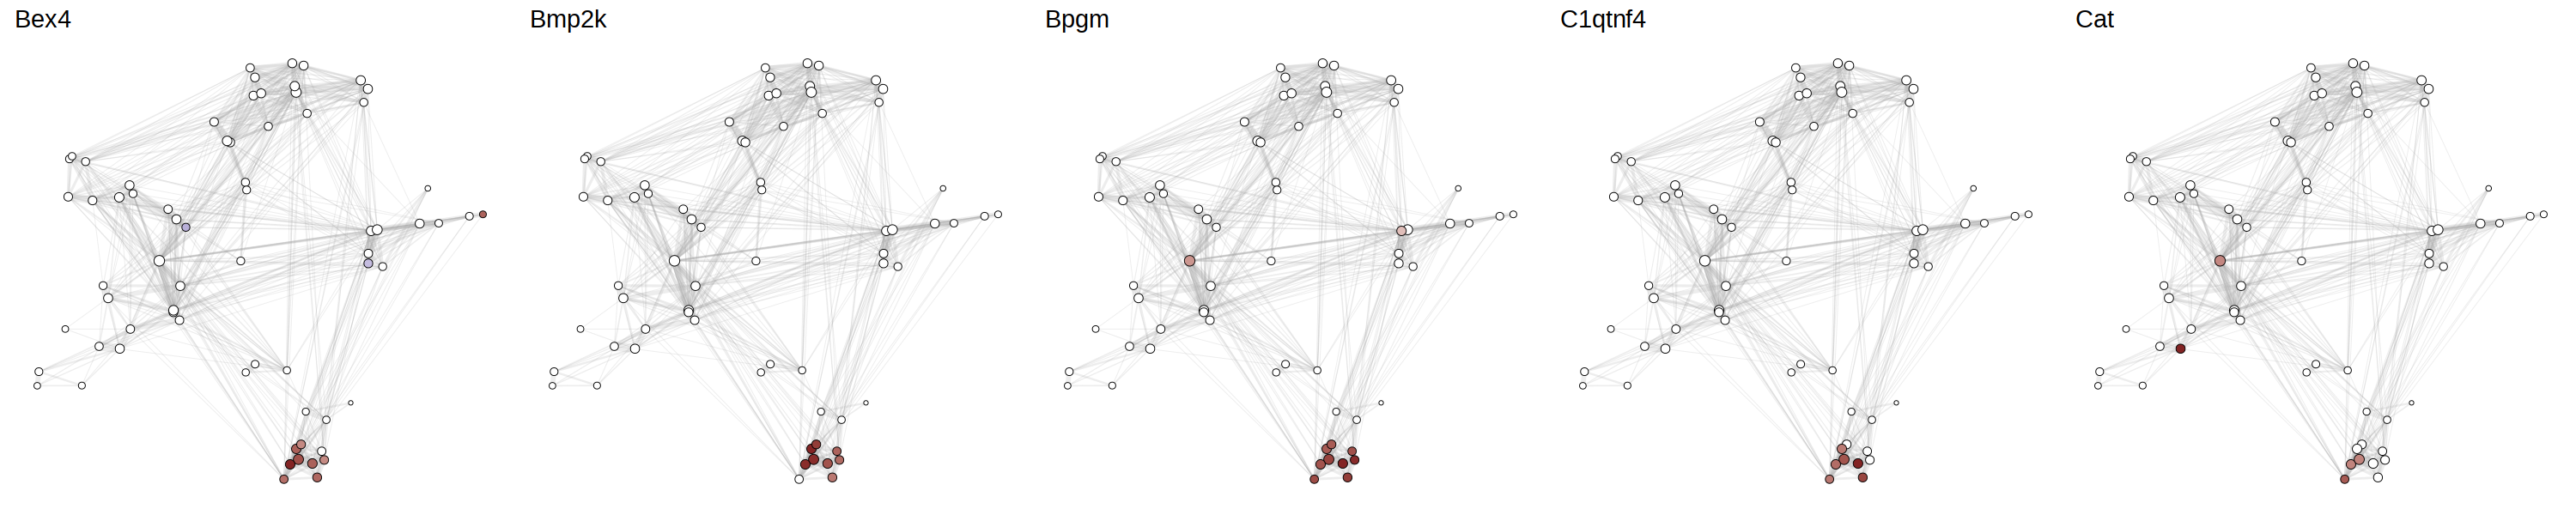

In [84]:
genes = head(modules_wgcna[modules_wgcna$cluster == 1,]$gene, 10)

plots = mclapply(genes , function(gene){
  p = suppressWarnings(plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "UMAP" , set_na_to_0 = TRUE)) + 
    ggtitle(gene) + theme(legend.position='none')
  return(p)
}, mc.cores=10)

options(repr.plot.height=5, repr.plot.width=25)
p = ggarrange(plotlist = plots , ncol = 5) 
p